In [ ]:
# Install required libraries
!pip install kaggle split-folders

# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Setup Kaggle API credentials
import os
import json

kaggle_json = {
    "username": "barelbar1",  # Replace with your Kaggle username
    "key": "bee247fb38ed506ebce83040fae21f7c"         # Replace with your Kaggle API key
}

# Save Kaggle API credentials
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set appropriate permissions
os.chmod("/root/.kaggle/kaggle.json", 600)

# Download the dataset from Kaggle
!kaggle datasets download -d muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten

# Extract the dataset
import zipfile
with zipfile.ZipFile("fruit-and-vegetable-disease-healthy-vs-rotten.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

# Define the dataset path
dataset_path = "/content/data/Fruit And Vegetable Diseases Dataset"

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    raise ValueError(f"The provided input folder '{dataset_path}' does not exist!")

# Split the dataset into train and test sets (80% train, 20% test)
import splitfolders

splitfolders.ratio(
    dataset_path,                      # Input folder
    output="/content/data/split_data", # Output folder
    seed=42,                           # Seed for reproducibility
    ratio=(0.8, 0.2)                   # Ratio: 80% train, 20% test
)

# Verify the folder structure
print("Folder structure after splitting:")
!ls /content/data/split_data

# Verify the contents of the train and test folders
print("\nTrain folder contents:")
!ls /content/data/split_data/train

print("\nTest folder contents:")
!ls /content/data/split_data/test



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Data Preprocessing and Augmentation

We preprocess the dataset by resizing images to a fixed size of 128x128 and normalizing pixel values to have a mean of 0.5 and a standard deviation of 0.5. For training, data augmentation techniques like random horizontal flipping, rotation, and zooming are applied to improve the model's robustness. Testing data is only resized and normalized to maintain consistency during evaluation.

The processed dataset is then loaded into `DataLoader` objects for efficient batching during training and testing.


In [ ]:
# Import necessary libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for training and testing
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),           # Resize all images to 128x128
    transforms.RandomHorizontalFlip(),       # Apply random horizontal flip
    transforms.RandomRotation(10),          # Apply random rotation up to 10 degrees
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  # Simulate zoom by cropping and resizing
    transforms.ToTensor(),                  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))    # Normalize to mean=0.5, std=0.5
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),           # Resize all images to 128x128
    transforms.ToTensor(),                  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))    # Normalize to mean=0.5, std=0.5
])

# Load train and test datasets
train_dataset = datasets.ImageFolder(root="/content/data/split_data/train", transform=transform_train)
test_dataset = datasets.ImageFolder(root="/content/data/split_data/test", transform=transform_test)

# Create DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print dataset size
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")


Training samples: 23426
Testing samples: 5865


## Step 3: Model Architecture

We design a custom convolutional neural network (CNN) for the binary classification task (Healthy vs. Rotten). The architecture includes:
- **3 Convolutional Layers**: Extract features from the images.
- **Pooling Layers**: Downsample feature maps.
- **Fully Connected Layers**: Perform classification.
- **Dropout**: Regularization to prevent overfitting.

The model takes RGB images (3 channels) as input and outputs predictions for 2 classes (Healthy and Rotten).


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Define a custom CNN model
class FruitVegCNN(nn.Module):
    def __init__(self):
        super(FruitVegCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Input: RGB (3 channels)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # Pooling layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # Fully connected layer
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 28)  # Output: 28 classes (Healthy/Rotten for 14 items)
        self.dropout = nn.Dropout(0.3)  # Dropout for regularization

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Convolution -> ReLU -> Pooling
        x = self.pool(F.relu(self.conv2(x)))  # Convolution -> ReLU -> Pooling
        x = self.pool(F.relu(self.conv3(x)))  # Convolution -> ReLU -> Pooling
        x = x.view(-1, 128 * 16 * 16)  # Flatten the tensor
        x = F.relu(self.fc1(x))  # Fully connected -> ReLU
        x = self.dropout(x)  # Apply dropout
        x = F.relu(self.fc2(x))  # Fully connected -> ReLU
        x = self.fc3(x)  # Fully connected -> Output
        return x

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FruitVegCNN().to(device)

# Print the model summary
print(model)


FruitVegCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=28, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## Step 4: Training the Model

We train the custom CNN model using the following steps:
- **Loss Function**: CrossEntropyLoss, suitable for multi-class classification.
- **Optimizer**: Adam optimizer with a learning rate of 0.001.
- **Training Loop**:
  - Forward pass to calculate predictions.
  - Backward pass to compute gradients and update weights.
  - Track average training loss for each epoch.
- **Validation**:
  - Evaluate model accuracy on the test dataset after each epoch.

The model is trained for 10 epochs, and the final model weights are saved as `fruit_veg_cnn.pth`.


In [ ]:
import torch.optim as optim  # Ensure optimizer module is imported

# Adjust the model output to match the dataset
model = FruitVegCNN().to(device)

# Training parameters
num_epochs = 10
criterion = nn.CrossEntropyLoss()  # Loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Define optimizer

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation on test set
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

# Save the trained model
torch.save(model.state_dict(), "fruit_veg_cnn_multiclass.pth")
print("Model saved as 'fruit_veg_cnn_multiclass.pth'")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10], Train Loss: 1.6514, Test Accuracy: 73.04%
Epoch [2/10], Train Loss: 0.8937, Test Accuracy: 79.97%
Epoch [3/10], Train Loss: 0.7001, Test Accuracy: 83.19%
Epoch [4/10], Train Loss: 0.5971, Test Accuracy: 85.93%
Epoch [5/10], Train Loss: 0.5270, Test Accuracy: 86.22%
Epoch [6/10], Train Loss: 0.4747, Test Accuracy: 87.43%
Epoch [7/10], Train Loss: 0.4237, Test Accuracy: 87.42%
Epoch [8/10], Train Loss: 0.4148, Test Accuracy: 89.00%
Epoch [9/10], Train Loss: 0.3709, Test Accuracy: 90.18%
Epoch [10/10], Train Loss: 0.3458, Test Accuracy: 91.25%
Model saved as 'fruit_veg_cnn_multiclass.pth'


## Step 5: Evaluating the Model with Visualization

### Objectives:
1. **Metrics**:
   - Generate a classification report with accuracy, precision, recall, and F1-score for each class.
2. **Confusion Matrix**:
   - Visualize the confusion matrix to analyze per-class performance.
3. **Training Trends**:
   - Plot training loss and test accuracy to observe trends over epochs.

### Visualization:
- A **line plot** shows how training loss and test accuracy evolve over epochs.
- A **confusion matrix** displays how well the model predicts each class.

### Interpretation:
- The classification report highlights performance for each class, identifying potential weaknesses.
- The confusion matrix shows common misclassifications, providing insights into where the model struggles.


<ipython-input-11-fa553dd0a2c6>:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fruit_veg_cnn_multiclass.pth", map_location=device))


Classification Report:
                      precision    recall  f1-score   support

      Apple__Healthy       0.98      0.95      0.96       488
       Apple__Rotten       0.93      0.92      0.92       586
     Banana__Healthy       0.93      0.98      0.95       400
      Banana__Rotten       0.96      0.98      0.97       560
 Bellpepper__Healthy       0.92      0.69      0.79       123
  Bellpepper__Rotten       0.62      0.55      0.59       119
     Carrot__Healthy       0.89      0.89      0.89       124
      Carrot__Rotten       0.71      0.86      0.78       116
   Cucumber__Healthy       0.74      1.00      0.85       122
    Cucumber__Rotten       0.84      0.77      0.80       119
      Grape__Healthy       0.76      0.95      0.84        40
       Grape__Rotten       0.89      0.80      0.84        40
      Guava__Healthy       0.93      0.97      0.95        40
       Guava__Rotten       0.69      0.88      0.77        40
     Jujube__Healthy       0.95      0.90     

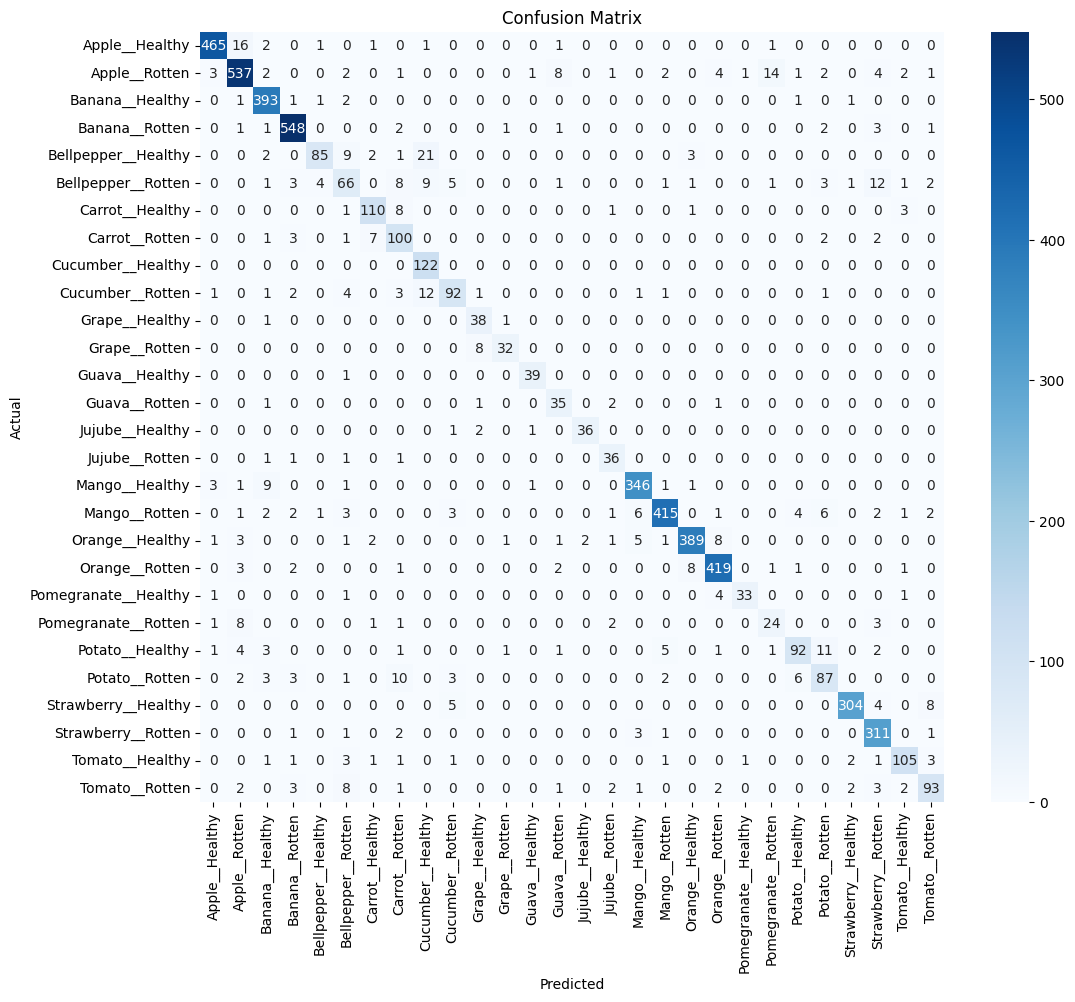

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the model architecture (ensure it matches the saved model)
class FruitVegCNN(nn.Module):
    def __init__(self):
        super(FruitVegCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 28)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model and load saved weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FruitVegCNN().to(device)
model.load_state_dict(torch.load("fruit_veg_cnn_multiclass.pth", map_location=device))
model.eval()  # Set the model to evaluation mode

# Evaluate model on the test set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

# Confusion Matrix
conf_mat = confusion_matrix(all_labels, all_preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
